# Neuronske mreze - teorijski pregled

Ova biljeznica je teorijska podloga za `autoencoder_klasifikator.ipynb` - binarni
klasifikator ("sum" vs. "vozilo") izgradjen kao autoencoder, treniran na `data/raw/background`
(sum) i evaluiran i na `data/raw/vehicle` (vozilo).

Redoslijed je namjerno postupan, svaka tema rjesava ogranicenje prethodne:

1. **Perceptron** - najjednostavniji umjetni neuron, ali ne moze rijesiti nelinearne probleme (XOR)
2. **Neuronska mreza (MLP)** - dodavanjem skrivenih slojeva + backpropagation rjesava se XOR
3. **DNN (duboka neuronska mreza)** - vise skrivenih slojeva reprezentacijski je ucinkovitije od
   jednog sirokog sloja, ali dubina uvodi novi problem (vanishing/exploding gradient)
4. **CNN** - DNN (gusto povezana mreza) ne iskoristava prostornu strukturu slikovnih/mrezastih
   podataka (npr. spektrograma); konvolucija + dijeljenje parametara to rjesava
5. **RNN** - ni MLP ni CNN ne pamte redoslijed ulaza kroz vrijeme, RNN uvodi memoriju (skriveno
   stanje)
6. **Autoencoder** - koristi ideje iz 1-5 da se **bez oznaka** (unsupervised) nauci "izgled"
   jedne klase (sum), a onda se greska rekonstrukcije koristi kao signal za binarnu klasifikaciju

Svaka sekcija ima kratku teoriju, prijedloge izvora (`izvori/izvorX.md`) i mali prakticni primjer
na sintetickim podacima - stvarna primjena na nasim audio podacima je u `autoencoder_klasifikator.ipynb` i u `cnn_klasifikator.ipynb`

## 1. Perceptron

### Sto je perceptron?

Perceptron (**VIDJETI izvor11]**) je najjednostavniji model umjetnog neurona,
nadogradnja na McCulloch-Pittsov model neurona iz 1943. (**[VIDJETI izvor10]**) koji je imao
fiksne, rucno postavljene tezine. Perceptron uvodi **ucenje** tezina iz podataka.

**Matematicki model:**

$$ z = \sum_{i=1}^{n} w_i x_i + b $$

$$ \hat{y} = \begin{cases} 1 & \text{ako } z > 0 \\ 0 & \text{inace} \end{cases} $$

gdje su:
- $x_i$ - ulazne znacajke
- $w_i$ - tezine (uce se)
- $b$ - bias (pomak praga)
- step funkcija (ovo dole) - aktivacijska funkcija koja izlaz binarizira

**Pravilo ucenja (perceptron learning rule):**

Za svaki uzorak, ako je predikcija pogresna, tezine se azuriraju u smjeru koji smanjuje gresku:

$$ w_i \leftarrow w_i + \eta (y - \hat{y}) x_i $$

gdje je $\eta$ (eta) stopa ucenja (learning rate). Ovo je preteca gradient descenta koji koristimo
kod svih kasnijih arhitektura.

**Kljucno ogranicenje:** perceptron moze nauciti granicu odluke samo ako je ona **linearna**
(linearno separabilni problemi - npr. AND, OR). Klasican protuprimjer je **XOR** - ne postoji
ravna linija koja razdvaja klase XOR-a, pa ni jedan perceptron ne moze nauciti tu funkciju bez
obzira koliko dugo se trenira. Ovo ogranicenje je direktno motiviralo prelazak na visesojne mreze
(sekcija 2).

**Literatura:**
- McCulloch, W., Pitts, W. (1943) - A Logical Calculus of the Ideas Immanent in Nervous Activity
  (**VIDJETI izvori/izvor10.md**)
- Rosenblatt, F. (1958) - The Perceptron: A Probabilistic Model for Information Storage and
  Organization in the Brain (**VIDJETI izvori/izvor11.md**)
- video: https://www.youtube.com/watch?v=4Gac5I64LM4


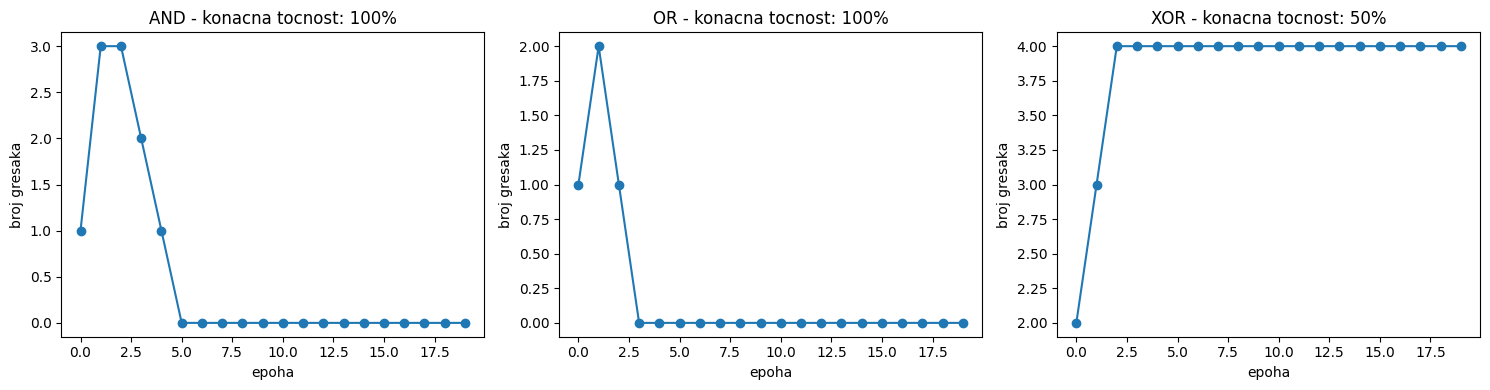

Perceptron nauci AND i OR (linearno separabilni) do 100% tocnosti.
XOR ostaje na 50-75% - greska nikad ne padne na 0 koliko god dugo treniramo,
jer ne postoji ravna linija koja razdvaja XOR klase. Ovo motivira MLP (sekcija 2).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


class Perceptron:
    # Najjednostavniji moguci perceptron - tezinska suma + step aktivacija.

    def __init__(self, n_features, lr=0.1):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr

    def predict(self, X):
        z = X @ self.w + self.b
        return (z > 0).astype(int)

    def fit(self, X, y, epochs=20):
        errors_per_epoch = []
        for _ in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_hat = self.predict(xi[None, :])[0]
                update = self.lr * (yi - y_hat)
                self.w += update * xi
                self.b += update
                errors += int(update != 0)
            errors_per_epoch.append(errors)
        return errors_per_epoch


# AND, OR (linearno separabilni) i XOR (NIJE linearno separabilan)
X_gate = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
gates = {
    "AND": np.array([0, 0, 0, 1]),
    "OR": np.array([0, 1, 1, 1]),
    "XOR": np.array([0, 1, 1, 0]),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_gate) in zip(axes, gates.items()):
    p = Perceptron(n_features=2, lr=0.1)
    errors = p.fit(X_gate, y_gate, epochs=20)
    acc = (p.predict(X_gate) == y_gate).mean()

    ax.plot(errors, marker="o")
    ax.set_title(f"{name} - konacna tocnost: {acc:.0%}")
    ax.set_xlabel("epoha")
    ax.set_ylabel("broj gresaka")

plt.tight_layout()
plt.show()

print("Perceptron nauci AND i OR (linearno separabilni) do 100% tocnosti.")
print("XOR ostaje na 50-75% - greska nikad ne padne na 0 koliko god dugo treniramo,")
print("jer ne postoji ravna linija koja razdvaja XOR klase. Ovo motivira MLP (sekcija 2).")


## 2. Neuronska mreza (Multi-Layer Perceptron / MLP)

### Kako MLP rjesava problem koji perceptron ne moze?

Dodavanjem **skrivenog sloja** (hidden layer) izmedju ulaza i izlaza, mreza moze
kombinirati vise linearnih granica u nelinearnu granicu odluke. Svaki neuron u skrivenom sloju
je zapravo mali perceptron (tezinska suma + aktivacija), ali sada aktivacijska funkcija mora biti
**derivabilna** (ne step funkcija) da bi backpropagation mogao racunati gradijente.

**Najcesce aktivacijske funkcije:**
- **Sigmoid**: $\sigma(z) = \frac{1}{1 + e^{-z}}$ - izlaz u (0, 1), koristan za vjerojatnosti,
  ali "zasiti" (gradijent ide u 0) za velike |z|
- **Tanh**: $\tanh(z)$ - izlaz u (-1, 1), centriran oko 0, ali ima isti problem zasicenja
- **ReLU**: $\max(0, z)$ - danas najcesce koristena, brza, ne zasicuje se za pozitivne vrijednosti

**Forward pass** (jedan sloj):

$$ a^{(l)} = f(W^{(l)} a^{(l-1)} + b^{(l)}) $$

gdje je $f$ aktivacijska funkcija, $W^{(l)}$ matrica tezina sloja $l$, a $a^{(l-1)}$ izlaz
prethodnog sloja (ili ulazni podaci za prvi sloj).

**Backpropagation** (**[VIDJETI izvor12]**): gresku na izlazu
racunamo pomocu funkcije gubitka (loss function, npr. MSE za regresiju ili cross-entropy za
klasifikaciju), a zatim je **chain rule-om** propagiramo unatrag kroz svaki sloj kako bismo
izracunali gradijent gubitka po svakoj tezini. Gradient descent zatim azurira sve tezine u smjeru
koji smanjuje gubitak:

$$ w \leftarrow w - \eta \frac{\partial L}{\partial w} $$

**Universal Approximation Theorem** ( **[VIDJETI izvor13]**) dokazuje da mreza sa
samo jednim (dovoljno sirokim) skrivenim slojem moze aproksimirati bilo koju kontinuiranu
funkciju. To je teoretsko opravdanje zasto MLP moze rijesiti XOR (i puno slozenije probleme) -
teorem ne kaze da ce gradient descent tu mrezu nuzno i pronaci, ali garantira da ona postoji.

**Literatura:**
- Rumelhart, D., Hinton, G., Williams, R. (1986) - Learning representations by
  back-propagating errors (**VIDJETI izvori/izvor12.md**)
- Cybenko, G. (1989) - Approximation by Superpositions of a Sigmoidal Function
  (**VIDJETI izvori/izvor13.md**)
- video: https://www.youtube.com/watch?v=aircAruvnKk


XOR ulazi:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Stvarni izlazi:    [0 1 1 0]
Predvidjeni izlazi: [0 1 1 0]
Tocnost: 100%  (perceptron gore nije mogao proci 75%)


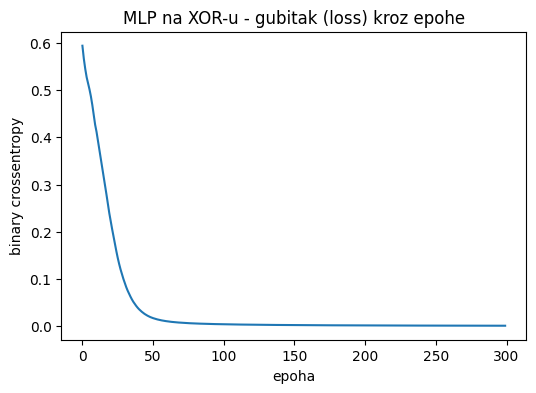

In [2]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype="float32")
y_xor = np.array([0, 1, 1, 0], dtype="float32")

# Isti XOR problem koji je "slomio" perceptron gore - sada s jednim skrivenim slojem
mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation="relu"),   # skriveni sloj - ovo perceptron nema
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
mlp.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05), loss="binary_crossentropy")

history = mlp.fit(X_xor, y_xor, epochs=300, verbose=0)

pred = (mlp.predict(X_xor, verbose=0) > 0.5).astype(int).flatten()
print("XOR ulazi:\n", X_xor)
print("Stvarni izlazi:   ", y_xor.astype(int))
print("Predvidjeni izlazi:", pred)
print(f"Tocnost: {(pred == y_xor).mean():.0%}  (perceptron gore nije mogao proci 75%)")

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"])
plt.title("MLP na XOR-u - gubitak (loss) kroz epohe")
plt.xlabel("epoha")
plt.ylabel("binary crossentropy")
plt.show()


## 3. DNN (Duboka neuronska mreza)

### Zasto ne samo dodati vise neurona u jedan skriveni sloj?

Universal Approximation Theorem (sekcija 2, izvor13) kaze da **jedan** dovoljno sirok skriveni sloj
moze aproksimirati bilo koju funkciju - ali "dovoljno sirok" u praksi moze znaciti eksponencijalno
mnogo neurona za slozene funkcije. **Duboka neuronska mreza (DNN)** je MLP s **vise skrivenih
slojeva** naslaganih jedan na drugi. Prednost dubine nad sirinom (**[VIDJETI izvor18]**) je da svaki sloj gradi na apstrakcijama proslog sloja - **hijerarhija
znacajki**: rani slojevi uce jednostavne, lokalne obrasce, a dublji slojevi ih kombiniraju u sve
slozenije koncepte. Za mnoge funkcije (npr. one sastavljene od ponavljajucih pod-obrazaca) duboka
uska mreza treba bitno manje ukupnih parametara od plitke siroke mreze da postigne istu tocnost.

**Forward pass** je isti kao kod MLP-a (sekcija 2), samo se ponavlja kroz vise slojeva:

$$ a^{(l)} = f\big(W^{(l)} a^{(l-1)} + b^{(l)}\big), \quad l = 1, \dots, L $$

### Cijena dubine: vanishing/exploding gradient

Backpropagation racuna gradijent gubitka po tezinama ranih slojeva mnozenjem gradijenata kroz
**sve** slojeve iza njih (lancano pravilo). Ako su ti faktori sustavno < 1 (npr. sigmoid/tanh
aktivacije cija je derivacija najvise 0.25), umnozak kroz mnogo slojeva eksponencijalno tezi nuli -
**vanishing gradient** - i rani slojevi se prakticki prestanu ucitavati/mijenjati. Ako su faktori
sustavno > 1, umnozak eksplodira. Ovo je **isti fenomen** koji cemo vidjeti kod RNN-a (sekcija 5),
samo sto se tamo gradijent mnozi kroz **vrijeme**, a ovdje kroz **dubinu** mreze.

Glorot i Bengio (**[VIDJETI izvor19]**) pokazuju da se problem moze ublaziti pazljivom
inicijalizacijom tezina i, sto je danas standardno, koristenjem **ReLU**
aktivacije umjesto sigmoid/tanh - ReLU ima derivaciju tocno 1 za pozitivne vrijednosti, pa ne
"gusi" gradijent na isti nacin.

**Literatura:**
- LeCun, Y., Bengio, Y., Hinton, G. (2015) - Deep Learning (**VIDJETI izvori/izvor18.md**)
- Glorot, X., Bengio, Y. (2010) - Understanding the difficulty of training deep feedforward
  neural networks (**VIDJETI izvori/izvor19.md**)
- video: https://www.youtube.com/watch?v=IHZwWFHWa-w


dubina= 1 skrivena sloja (sirina=8 svaki,   33 parametara) - test tocnost: 57%
dubina= 2 skrivena sloja (sirina=8 svaki,  105 parametara) - test tocnost: 64%
dubina= 4 skrivena sloja (sirina=8 svaki,  249 parametara) - test tocnost: 72%
dubina= 8 skrivena sloja (sirina=8 svaki,  537 parametara) - test tocnost: 48%


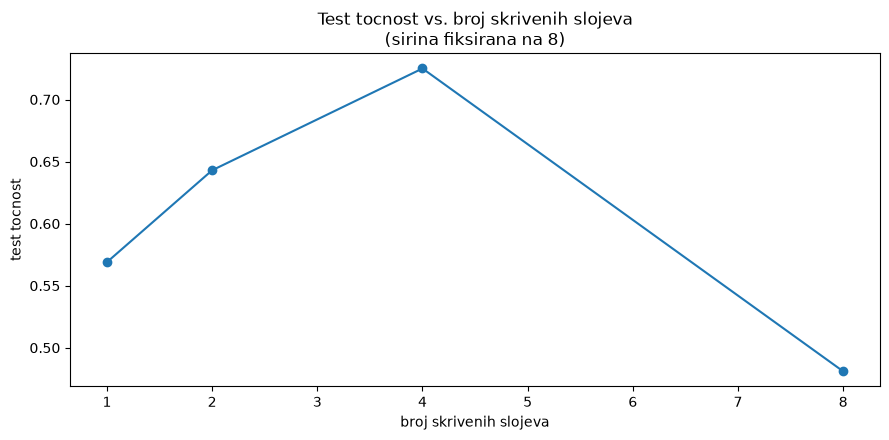


Uz FIKSNU sirinu sloja (8 neurona), dodavanje dubine bitno poboljsava tocnost na
problemu sahovnice - mreza gradi slozenu granicu kompozicijom vise jednostavnih,
umjesto da jedan sloj pokusa direktno nauciti cijeli slozeni obrazac. Ali kada dode do prevelike dubine
od 8 slojeva, tocnost naglo padne zbog tezeg treniranja (vanishing gradient, overfitting)


In [19]:
# zelimo genetirati neki tezak problem - 6x6 sahovnicu, to je naravno iznimno
# linearno neseparabilan problem, a kontroliramo samo dubinu mreze, svaki sloj
# ima isti broj neurona (8) znaci svaki sloj je iste sirine, samo definiramo broj slojeva

def make_checkerboard(n, rng, freq=3):
    X = rng.uniform(-1, 1, size=(n, 2)).astype("float32")
    y = (np.sign(np.sin(freq * np.pi * X[:, 0]) * np.sin(freq * np.pi * X[:, 1])) > 0).astype("float32")
    return X, y

data_rng = np.random.default_rng(7)
X_train_cb, y_train_cb = make_checkerboard(4000, data_rng)
X_test_cb, y_test_cb = make_checkerboard(1000, data_rng)

def build_dnn(depth, width=8):
    layers = [tf.keras.layers.Input(shape=(2,))]
    for _ in range(depth):
        layers.append(tf.keras.layers.Dense(width, activation="relu"))
    layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))
    return tf.keras.Sequential(layers)

depths = [1, 2, 4, 8]
depth_acc = {}
depth_models = {}
for depth in depths:
    tf.keras.utils.set_random_seed(3)
    model = build_dnn(depth)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss="binary_crossentropy")
    model.fit(X_train_cb, y_train_cb, epochs=60, batch_size=64, verbose=0)
    pred = (model.predict(X_test_cb, verbose=0) > 0.5).astype(int).flatten()
    acc = (pred == y_test_cb).mean()
    depth_acc[depth] = acc
    depth_models[depth] = model
    print(f"dubina={depth:2d} skrivena sloja (sirina=8 svaki, {model.count_params():4d} parametara)"
          f" - test tocnost: {acc:.0%}")

# Vizualizacija: tocnost vs. dubina, i granica odluke za najplicu i najdublju mrezu
xx, yy = np.meshgrid(np.linspace(-1, 1, 200), np.linspace(-1, 1, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype("float32")

fig, axes = plt.subplots(figsize=(9, 4.5))

axes.plot(depths, [depth_acc[d] for d in depths], marker="o")
axes.set_title("Test tocnost vs. broj skrivenih slojeva\n(sirina fiksirana na 8)")
axes.set_xlabel("broj skrivenih slojeva")
axes.set_ylabel("test tocnost")


plt.tight_layout()
plt.show()

print()
print("Uz FIKSNU sirinu sloja (8 neurona), dodavanje dubine bitno poboljsava tocnost na")
print("problemu sahovnice - mreza gradi slozenu granicu kompozicijom vise jednostavnih,")
print("umjesto da jedan sloj pokusa direktno nauciti cijeli slozeni obrazac. Ali kada dode do prevelike dubine")
print("od 8 slojeva, tocnost naglo padne zbog tezeg treniranja (vanishing gradient, overfitting)")


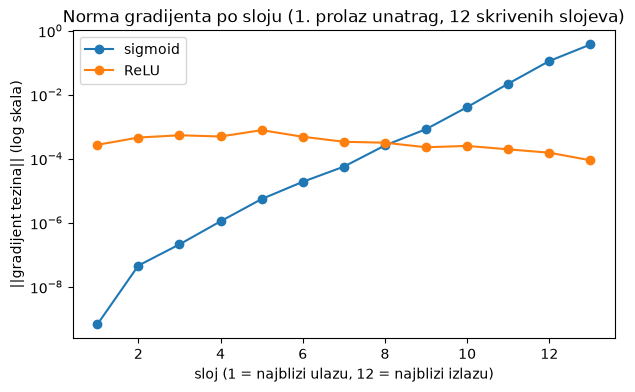

Kod sigmoid aktivacije gradijent kod ranih (ulaznih) slojeva je 7 redova velicine 
(gledamo sloj 12 koji uci dosta i onda sloj 1 koji je spao na jako mali gradijent)
manji nego kod izlaznih slojeva - ti slojevi se ucinkovito NE treniraju (vanishing
gradient). ReLU odrzava puno ujednaceniju velicinu gradijenta kroz svih 12 slojeva -
zato je danas standardna aktivacija za skrivene slojeve dubokih mreza.


In [21]:
# (b) Vanishing gradient kroz dubinu: sigmoid vs. ReLU. Gradimo vrlo duboku mrezu (12
# skrivenih slojeva) sa sigmoid aktivacijom i istu takvu s ReLU, pa nakon JEDNOG prolaska
# unatrag (backprop) mjerimo normu gradijenta tezina svakog sloja. Ako gradijent "iscezava"
# prema ranijim (nizim indeksom) slojevima, ti slojevi se prakticki ne uce.

def build_deep(activation, depth=12, width=16):
    layers = [tf.keras.layers.Input(shape=(2,))]
    for _ in range(depth):
        layers.append(tf.keras.layers.Dense(width, activation=activation))
    layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))
    return tf.keras.Sequential(layers)

def layer_gradient_norms(model, X, y):
    dnn_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Dense)]
    with tf.GradientTape() as tape:
        y_hat = model(X, training=True)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y, y_hat))
    grads = tape.gradient(loss, [l.kernel for l in dnn_layers])
    return [float(tf.norm(g)) for g in grads]

X_batch = tf.constant(X_train_cb[:256])
y_batch = tf.reshape(tf.constant(y_train_cb[:256]), (-1, 1))

grad_norms = {}
for name, activation in [("sigmoid", "sigmoid"), ("ReLU", "relu")]:
    tf.keras.utils.set_random_seed(5)
    model = build_deep(activation)
    grad_norms[name] = layer_gradient_norms(model, X_batch, y_batch)

plt.figure(figsize=(7, 4))
for name, norms in grad_norms.items():
    plt.semilogy(range(1, len(norms) + 1), norms, marker="o", label=name)
plt.title("Norma gradijenta po sloju (1. prolaz unatrag, 12 skrivenih slojeva)")
plt.xlabel("sloj (1 = najblizi ulazu, 12 = najblizi izlazu)")
plt.ylabel("||gradijent tezina|| (log skala)")
plt.legend()
plt.show()

print("Kod sigmoid aktivacije gradijent kod ranih (ulaznih) slojeva je 7 redova velicine ")
print("(gledamo sloj 12 koji uci dosta i onda sloj 1 koji je spao na jako mali gradijent)")
print("manji nego kod izlaznih slojeva - ti slojevi se ucinkovito NE treniraju (vanishing")
print("gradient). ReLU odrzava puno ujednaceniju velicinu gradijenta kroz svih 12 slojeva -")
print("zato je danas standardna aktivacija za skrivene slojeve dubokih mreza.")


## 4. CNN (Konvolucijska neuronska mreza)

### Sto DNN "ne vidi" kod slikovnih/mrezastih podataka?

Gusto povezan DNN (sekcija 3) tretira ulaz kao ravnu listu brojeva - ako je ulaz slika (ili
spektrogram, sto je slika frekvencija kroz vrijeme), DNN prvo "izravna" (flatten) sliku i time
**zaboravi prostorni odnos susjednih piksela**. Svaki piksel dobiva zasebnu tezinu za svaki neuron,
pa mreza mora zasebno nauciti prepoznati isti obrazac (npr. rub) na svakoj mogucoj poziciji u
slici - to je i skupo (puno parametara) i losije generalizira na pozicije koje nisu vidjene u
treningu.

**Konvolucijska neuronska mreza (CNN)** (**[VIDJETI izvor20]**) rjesava to
uvodjenjem konvolucijskog sloja:

$$ (I * K)(i, j) = \sum_{m}\sum_{n} I(i+m, j+n)\, K(m, n) $$

gdje je $I$ ulazna slika, a $K$ mali **filter (kernel)**, npr. 3x3. Filter "klize" preko cijele
slike i na svakoj poziciji racuna tezinsku sumu lokalnog prozora - rezultat je **feature map**.
Kljucna ideja je **dijeljenje parametara (weight sharing)**: isti filter (iste tezine) se koristi
na svakoj poziciji slike, sto daje dvije vazne posljedice:

- **puno manje parametara** nego gusti sloj iste "sirine" (filter od 3x3x1 ima 9 tezina, bez
  obzira na velicinu ulazne slike)
- **translacijska invarijantnost** - jednom naucen obrazac (npr. rub ili mrlja) prepoznaje se bez
  obzira gdje se u slici pojavi, jer isti filter "gleda" svaku poziciju

**Pooling** (najcesce max pooling) nakon konvolucije smanjuje prostornu rezoluciju feature mape
(npr. uzima maksimum svakog 2x2 prozora) - time mreza postaje robusnija na male pomake i smanjuje
broj parametara u dubljim slojevima. Tipicna CNN arhitektura slaze blokove
konvolucija -> aktivacija (ReLU) -> pooling, ponavljajuci ih vise puta (dubina, sekcija 3), a na
kraju dodaje jedan ili vise gustih (Dense) slojeva za konacnu klasifikaciju - ovaj obrazac je
popularizirao AlexNet (Krizhevsky, Sutskever, Hinton, 2012 - **[VIDJETI izvor21]**), koji je
pokazao da duboke CNN mreze drasticno nadmasuju dotadasnje pristupe klasifikaciji slika.

**Napomena za nas slucaj:** `scripts/legacy/Classify_Data_2.py` koristi tocno ovakvu CNN
arhitekturu nad `data/spectrograms/` (spektrogrami zvuka pretvoreni u slike) za **supervizirano**
razlikovanje BG (sum) vs. Veh (vozilo) - obje klase su oznacene i vidjene u treningu. Ovo je bitno
razumjeti prije autoencodera (sekcija 6): tamo cemo isti tip prostornih znacajki-vektorskih
podataka obradjivati bez oznaka druge klase, pa cemo kasnije direktno usporedjivati ova dva
pristupa.

**Literatura:**
- LeCun, Y., Bottou, L., Bengio, Y., Haffner, P. (1998) - Gradient-Based Learning Applied to
  Document Recognition (**VIDJETI izvori/izvor20.md**)
- Krizhevsky, A., Sutskever, I., Hinton, G. (2012) - ImageNet Classification with Deep
  Convolutional Neural Networks (**VIDJETI izvori/izvor21.md**)
- video: https://www.youtube.com/watch?v=KuXjwB4LzSA


In [22]:
# (a) Translacijska invarijantnost: DNN vs. CNN. Generiramo sinteticke "slike"
# (16x16, sumovita pozadina) s jednim od dva lokalna oblika - "plus" (klasa 0) ili "kvadrat"
# (klasa 1) - postavljenim na NASUMICNU poziciju. Kljucni eksperiment: OBA modela treniramo
# samo na oblicima iz GORNJE polovice slike, a testiramo i na oblicima iz DONJE polovice
# (pozicije koje mreza NIKAD nije vidjela u treningu). DNN (flatten + potpuno povezani
# slojevi) nema pojma o prostornoj strukturi pa mora nauciti "gdje" gledati za svaku vidjenu
# poziciju - CNN dijeli iste filtre na svim pozicijama pa bi trebala generalizirati.

size = 16

def draw_shape(img, r, c, shape):
    if shape == 0:       # "plus"
        img[r + 1, c] = 1.0
        img[r, c + 1] = 1.0
        img[r + 1, c + 1] = 1.0
        img[r + 2, c + 1] = 1.0
        img[r + 1, c + 2] = 1.0
    else:                 # "kvadrat" (puni 3x3 blok)
        img[r:r + 3, c:c + 3] = 1.0

def make_shape_dataset(n, rng, row_range, col_range=(0, size - 3)):
    X = rng.normal(0, 0.05, size=(n, size, size, 1)).astype("float32")
    y = rng.integers(0, 2, size=n).astype("float32")
    for i in range(n):
        r = rng.integers(row_range[0], row_range[1] + 1)
        c = rng.integers(col_range[0], col_range[1] + 1)
        draw_shape(X[i, :, :, 0], r, c, int(y[i]))
    return np.clip(X, 0.0, 1.0).astype("float32"), y

img_rng = np.random.default_rng(11)
train_rows = (0, 4)      # gornja polovica
unseen_rows = (10, 13)   # donja polovica - NIKAD vidjeno u treningu

X_train_img, y_train_img = make_shape_dataset(1500, img_rng, train_rows)
X_val_img, y_val_img = make_shape_dataset(300, img_rng, train_rows)
X_unseen_img, y_unseen_img = make_shape_dataset(300, img_rng, unseen_rows)

def build_dnn_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(size, size, 1)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

def build_cnn_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(size, size, 1)),
        tf.keras.layers.Conv2D(8, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

results_img = {}
trained_models = {}
for name, builder in [("DNN", build_dnn_model), ("CNN", build_cnn_model)]:
    tf.keras.utils.set_random_seed(21)
    model = builder()
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="binary_crossentropy")
    model.fit(X_train_img, y_train_img, epochs=15, batch_size=32, verbose=0,
              validation_data=(X_val_img, y_val_img))

    acc_seen = ((model.predict(X_val_img, verbose=0) > 0.5).astype(int).flatten() == y_val_img).mean()
    acc_unseen = ((model.predict(X_unseen_img, verbose=0) > 0.5).astype(int).flatten() == y_unseen_img).mean()
    results_img[name] = (acc_seen, acc_unseen)
    trained_models[name] = model
    print(f"{name:16s} ({model.count_params():5d} parametara) - "
          f"tocnost na vidjenim pozicijama: {acc_seen:.0%}, na NEVIDJENIM pozicijama: {acc_unseen:.0%}")

print()
print("DNN uci prepoznavati oblik NA ODREDJENOJ poziciji (gornja polovica) i losije")
print("generalizira kad se isti oblik pojavi na novoj poziciji. CNN, zahvaljujuci dijeljenju")
print("filtera na svim pozicijama, prepoznaje oblik bez obzira gdje se pojavi.")


DNN              (18561 parametara) - tocnost na vidjenim pozicijama: 100%, na NEVIDJENIM pozicijama: 51%
CNN              ( 1265 parametara) - tocnost na vidjenim pozicijama: 100%, na NEVIDJENIM pozicijama: 97%

DNN uci prepoznavati oblik NA ODREDJENOJ poziciji (gornja polovica) i losije
generalizira kad se isti oblik pojavi na novoj poziciji. CNN, zahvaljujuci dijeljenju
filtera na svim pozicijama, prepoznaje oblik bez obzira gdje se pojavi.


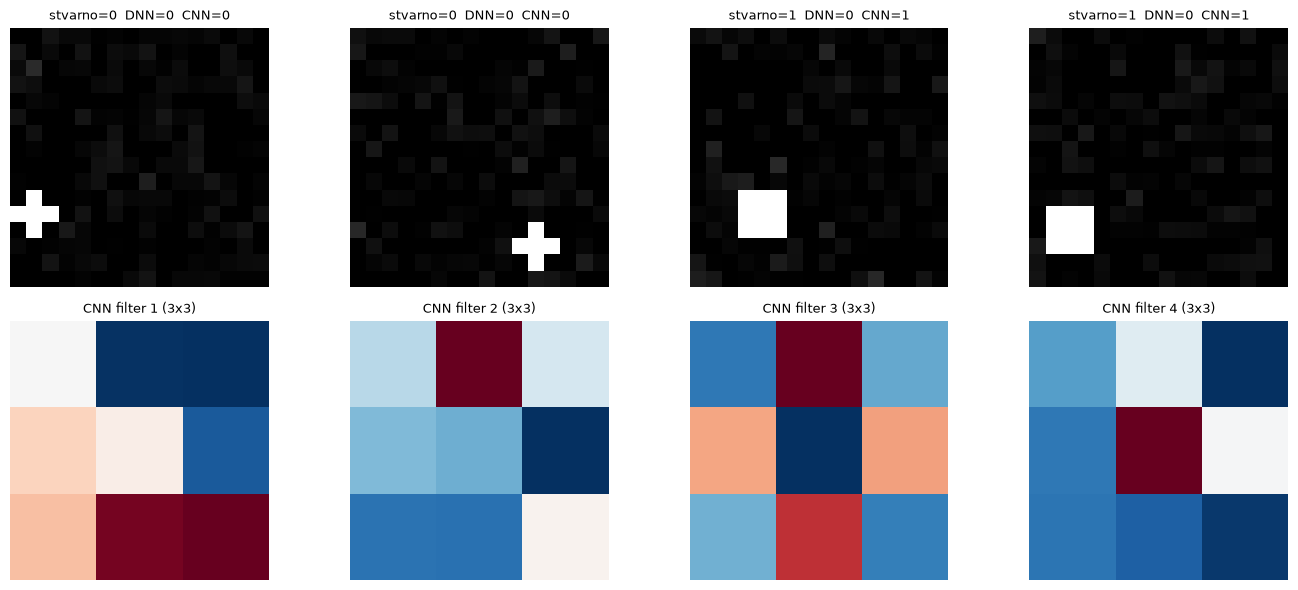

In [12]:
# (b) Vizualizacija: primjeri "nevidjenih" test slika s predikcijama oba modela (gornji red),
# te nauceni konvolucijski filtri prvog sloja CNN-a (donji red) - svaki filter je 3x3 matrica
# tezina koja se primjenjuje na SVAKU poziciju slike (dijeljenje parametara).

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i in range(4):
    img = X_unseen_img[i, :, :, 0]
    true_label = int(y_unseen_img[i])
    dense_pred = int(trained_models["DNN"].predict(X_unseen_img[i:i + 1], verbose=0)[0, 0] > 0.5)
    cnn_pred = int(trained_models["CNN"].predict(X_unseen_img[i:i + 1], verbose=0)[0, 0] > 0.5)
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"stvarno={true_label}  DNN={dense_pred}  CNN={cnn_pred}", fontsize=9)
    axes[0, i].axis("off")

first_conv = next(l for l in trained_models["CNN"].layers if isinstance(l, tf.keras.layers.Conv2D))
filters, _ = first_conv.get_weights()
for i in range(min(4, filters.shape[-1])):
    axes[1, i].imshow(filters[:, :, 0, i], cmap="RdBu")
    axes[1, i].set_title(f"CNN filter {i + 1} (3x3)", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


## 5. RNN (Recurrent Neural Network)

### Zasto ni MLP ni DNN ni CNN nisu dovoljni za sekvence?

MLP (sekcija 2), DNN (sekcija 3) i CNN (sekcija 4) obradjuju svaki ulaz nezavisno - CNN dodaje
prostornu strukturu (susjedni pikseli), ali ni ona nema pojma o "redoslijedu kroz vrijeme". To je
problem za sekvencijalne podatke kao sto je **zvuk** (vremenski niz) - npr. bitno je ne samo koje
su frekvencije prisutne, nego i kako se mijenjaju kroz vrijeme (dolazak vs. odlazak vozila).

**Elman network** (**[VIDJETI izvor14]**) uvodi rekurentnu vezu: skriveno stanje
$h_t$ u trenutku $t$ ovisi i o trenutnom ulazu $x_t$ **i** o skrivenom stanju iz prethodnog
koraka $h_{t-1}$:

$$ h_t = f(W_x x_t + W_h h_{t-1} + b) $$

Ovo skriveno stanje djeluje kao "memorija" koja se prenosi kroz vrijeme.

**Problem: vanishing gradient.** Kad se backpropagation radi kroz mnogo vremenskih koraka
(backpropagation through time, BPTT), gradijenti se mnoze kroz svaki korak i mogu eksponencijalno
isceznuti (ili eksplodirati) - **isti fenomen kao kod dubokih mreza (sekcija 3)**, samo sto se ovdje
mnozenje odvija kroz vrijeme umjesto kroz slojeve. Rezultat: obican RNN prakticki ne moze nauciti
ovisnosti izmedju udaljenih vremenskih koraka (npr. povezati pocetak i kraj duge sekvence).

**LSTM** (**[VIDJETI izvor15]**) rjesava taj problem uvodjenjem
**cell state-a** (odvojena "memorijska traka" kroz koju gradijent moze teci gotovo nepromijenjen)
i tri **gate mehanizma**:
- **forget gate** - sto zaboraviti iz proslog stanja
- **input gate** - sto novo zapamtiti iz trenutnog ulaza
- **output gate** - sto od trenutnog stanja propustiti na izlaz

**Napomena za nas slucaj:** u iducoj biljeznici (autoencoder klasifikator) radimo na
**feature-vektorima** (RMS, ZCR, spektralne znacajke, MFCC - agregirane preko cijelog 2s
isjecka), a ne na sirovom vremenskom nizu, pa tamo ne koristimo RNN/LSTM sloj direktno. Ipak, ovo
je vazna teorijska stanica jer objasnjava alternativu - da smo modelirali sirovi audio kao
sekvencu (npr. niz MFCC frame-ova kroz vrijeme umjesto njihovog prosjeka), LSTM bi bio prirodan
izbor arhitekture.

**Literatura:**
- Elman, J. (1990) - Finding Structure in Time (**VIDJETI izvori/izvor14.md**)
- Hochreiter, S., Schmidhuber, J. (1997) - Long Short-Term Memory (**VIDJETI izvori/izvor15.md**)
- video: https://www.youtube.com/watch?v=AsNTP8Kwu80
- video: https://www.youtube.com/watch?v=YCzL96nL7j0


Baseline MSE (model koji uvijek predvidja prosjek, ne gleda ulaz): 0.169
Ako arhitektura ne moze nauciti pamtiti dugorocno, njen MSE ce ostati blizu ovog broja.



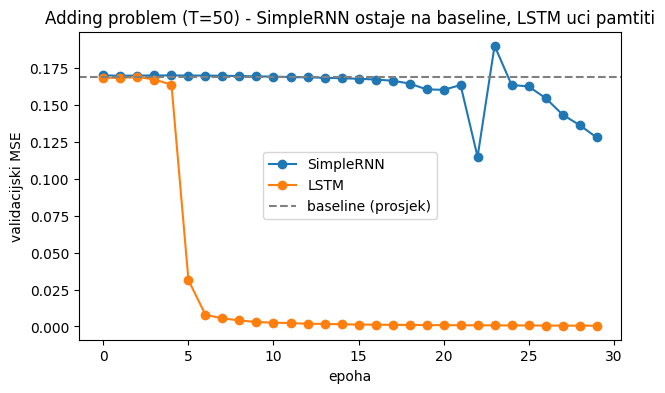

SimpleRNN: finalni val. MSE = 0.1282
LSTM: finalni val. MSE = 0.0005


In [3]:
# "Adding problem" - klasican benchmark iz originalnog LSTM rada (Hochreiter i Schmidhuber,
# 1997, izvor15) bas napravljen da demonstrira vanishing gradient. Ulaz su dva kanala kroz
# T koraka: (1) nasumicne vrijednosti u [0, 1], (2) "marker" kanal koji je 0 svugdje osim na
# dvije nasumicne pozicije (jedna u prvoj, jedna u drugoj polovici niza). Cilj je zbrojiti
# tocno te dvije oznacene vrijednosti - model MORA pamtiti informaciju s pocetka niza sve do
# kraja da bi ovo rijesio.

def make_adding_problem(n, T, rng):
    values = rng.uniform(0, 1, size=(n, T, 1)).astype("float32")
    markers = np.zeros((n, T, 1), dtype="float32")
    y = np.zeros((n,), dtype="float32")
    for i in range(n):
        i1 = rng.integers(0, T // 2)
        i2 = rng.integers(T // 2, T)
        markers[i, i1, 0] = 1.0
        markers[i, i2, 0] = 1.0
        y[i] = values[i, i1, 0] + values[i, i2, 0]
    return np.concatenate([values, markers], axis=-1), y

T = 50
data_rng = np.random.default_rng(0)
X_train, y_train = make_adding_problem(6000, T, data_rng)
X_test, y_test = make_adding_problem(1000, T, data_rng)

baseline_mse = np.mean((y_test - y_train.mean()) ** 2)
print(f"Baseline MSE (model koji uvijek predvidja prosjek, ne gleda ulaz): {baseline_mse:.3f}")
print("Ako arhitektura ne moze nauciti pamtiti dugorocno, njen MSE ce ostati blizu ovog broja.\n")

results = {}
for name, layer in [
    ("SimpleRNN", tf.keras.layers.SimpleRNN(20)),
    ("LSTM", tf.keras.layers.LSTM(20)),
]:
    tf.keras.utils.set_random_seed(1)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(T, 2)),
        layer,
        tf.keras.layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="mse")
    hist = model.fit(X_train, y_train, epochs=30, batch_size=64, verbose=0,
                      validation_data=(X_test, y_test))
    results[name] = hist.history["val_loss"]

plt.figure(figsize=(7, 4))
for name, loss in results.items():
    plt.plot(loss, marker="o", label=name)
plt.axhline(baseline_mse, color="gray", linestyle="--", label="baseline (prosjek)")
plt.title(f"Adding problem (T={T}) - SimpleRNN ostaje na baseline, LSTM uci pamtiti")
plt.xlabel("epoha")
plt.ylabel("validacijski MSE")
plt.legend()
plt.show()

for name, loss in results.items():
    print(f"{name}: finalni val. MSE = {loss[-1]:.4f}")


## 6. Autoencoder

### Encoder -> bottleneck -> decoder

Autoencoder (**[VIDJETI izvor16]**) je mreza koja uci
rekonstruirati **vlastiti ulaz**. Sastoji se od dva dijela:

- **Encoder** - komprimira ulaz $x$ u nisko-dimenzionalnu reprezentaciju (latentni prostor,
  "bottleneck") $z = f_{enc}(x)$
- **Decoder** - iz $z$ pokusava rekonstruirati original: $\hat{x} = f_{dec}(z)$

Trenira se minimiziranjem **reconstruction lossa** (najcesce MSE):

$$ L = \| x - \hat{x} \|^2 $$

Kljucno: ovo je **unsupervised** ucenje - ne treba nam nikakva labela, cilj je samo da izlaz bude
sto slicniji ulazu. Bottleneck sloj prisiljava mrezu da nauci samo najbitnije, kompresirane
znacajke ulaza (slicno PCA, ali autoencoder moze nauciti i nelinearne odnose jer koristi
nelinearne aktivacije, kao MLP iz sekcije 2). Enkoder i dekoder mogu biti izgradjeni od gustih
(Dense) slojeva, kao u sintetickom primjeru ispod, ili - ako je ulaz slika/spektrogram - od
konvolucijskih slojeva (sekcija 4), pri cemu se koristi transponirana konvolucija za "sirenje"
bottleneck reprezentacije natrag na originalnu velicinu slike.

### Autoencoder kao binarni klasifikator (anomaly detection)

Ideja (**[VIDJETI izvor17]**) koju koristimo u iducoj biljeznici:

1. Autoencoder treniramo **iskljucivo na jednoj klasi** - u nasem slucaju `background`/sum
2. Mreza nauci dobro rekonstruirati **samo** obrasce koji slice na sum
3. Kad joj damo primjer druge klase (`vehicle`/vozilo), koju **nikad nije vidjela u treningu**,
   rekonstrukcija ce biti losa (mreza ne zna kako komprimirati/dekomprimirati taj obrazac)
4. Gresku rekonstrukcije (MSE izmedju ulaza i izlaza) koristimo kao **anomaly score**
5. Prag (threshold) na toj gresci pretvara autoencoder u binarni klasifikator:
   ispod praga -> "sum", iznad praga -> "vozilo"

**Zasto je ovo vazno usporediti s CNN-om (sekcija 4):** `scripts/legacy/Classify_Data_2.py`
koristi CNN koji direktno uci razliku BG vs. Veh **supervizirano**, iz **oba** oznacena skupa
podataka - mreza tijekom treninga vidi primjere obje klase i uci granicu izmedju njih. Autoencoder
pristup je fundamentalno drugaciji: uci samo iz jedne klase (bez oznaka), a "vozilo" prepoznaje
posredno, kao ono sto **ne moze dobro rekonstruirati**. 

**Literatura:**
- Hinton, G., Salakhutdinov, R. (2006) - Reducing the Dimensionality of Data with Neural
  Networks (**VIDJETI izvori/izvor16.md**)
- Sakurada, M., Yairi, T. (2014) - Anomaly Detection Using Autoencoders with Nonlinear
  Dimensionality Reduction (**VIDJETI izvori/izvor17.md**)
- video: https://www.youtube.com/watch?v=9zKuYvjFFS8


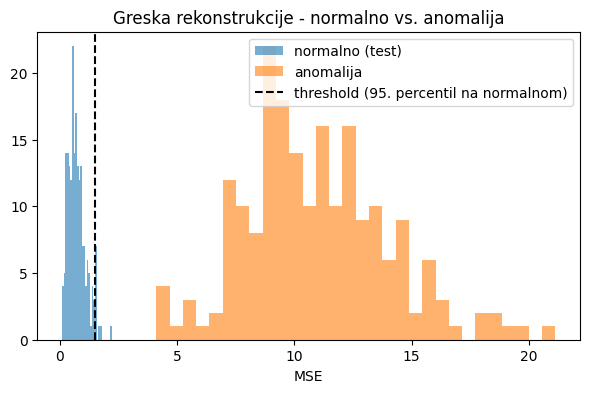

Threshold (95. percentil na normalnom skupu): 1.486
Anomalije ispravno oznacene (TPR): 100%
Normalni uzorci pogresno oznaceni kao anomalija (FPR): 5%

Isti princip primjenjujemo u sljedecoj biljeznici (autoencoder_klasifikator.ipynb),
samo sto 'normalno' = data/raw/background, a 'anomalija' = data/raw/vehicle.


In [4]:
# Sinteticka demonstracija koncepta prije primjene na stvarne audio znacajke (iduca biljeznica):
# treniramo autoencoder SAMO na "normalnoj" grupi tocaka i gledamo raste li greska rekonstrukcije
# na "anomalnoj" grupi koju mreza nikad nije vidjela.

tf.keras.utils.set_random_seed(42)

n_dim = 10
normal = rng.normal(loc=0.0, scale=1.0, size=(1000, n_dim)).astype("float32")
anomaly = rng.normal(loc=4.0, scale=1.5, size=(200, n_dim)).astype("float32")

normal_train = normal[:800]
normal_test = normal[800:]

autoencoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_dim,)),
    tf.keras.layers.Dense(6, activation="relu"),
    tf.keras.layers.Dense(3, activation="relu"),   # bottleneck
    tf.keras.layers.Dense(6, activation="relu"),
    tf.keras.layers.Dense(n_dim, activation="linear"),
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(normal_train, normal_train, epochs=60, batch_size=32, verbose=0)

def reconstruction_error(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

err_normal = reconstruction_error(autoencoder, normal_test)
err_anomaly = reconstruction_error(autoencoder, anomaly)

plt.figure(figsize=(7, 4))
plt.hist(err_normal, bins=30, alpha=0.6, label="normalno (test)")
plt.hist(err_anomaly, bins=30, alpha=0.6, label="anomalija")
plt.axvline(np.percentile(err_normal, 95), color="black", linestyle="--",
            label="threshold (95. percentil na normalnom)")
plt.title("Greska rekonstrukcije - normalno vs. anomalija")
plt.xlabel("MSE")
plt.legend()
plt.show()

threshold = np.percentile(err_normal, 95)
tpr = (err_anomaly > threshold).mean()
fpr = (err_normal > threshold).mean()
print(f"Threshold (95. percentil na normalnom skupu): {threshold:.3f}")
print(f"Anomalije ispravno oznacene (TPR): {tpr:.0%}")
print(f"Normalni uzorci pogresno oznaceni kao anomalija (FPR): {fpr:.0%}")
print()
print("Isti princip primjenjujemo u sljedecoj biljeznici (autoencoder_klasifikator.ipynb),")
print("samo sto 'normalno' = data/raw/background, a 'anomalija' = data/raw/vehicle.")


## Zakljucak i sljedeci korak

Pregledali smo put od najjednostavnijeg umjetnog neurona do autoencodera:

| Model | Rjesava | Ogranicenje koje ostavlja |
|---|---|---|
| Perceptron | Ucenje tezina iz podataka (umjesto rucnog postavljanja) | Samo linearno separabilni problemi |
| MLP (NN) | Nelinearne granice odluke (skriveni slojevi + backprop) | Plitki sloj treba eksponencijalno vise neurona za slozene funkcije |
| DNN | Reprezentacijski ucinkovitije ucenje slozenih funkcija (hijerarhija znacajki kroz dubinu) | Ne iskoristava prostornu strukturu slike/mreze podataka; vanishing/exploding gradient |
| CNN | Prostorna struktura, dijeljenje parametara, translacijska invarijantnost | i dalje ne pamti redoslijed/vrijeme |
| RNN / LSTM | Sekvencijalni podaci, memorija kroz vrijeme | I dalje treba oznake (supervised) |
| Autoencoder | Ucenje bez oznaka (unsupervised), rekonstrukcija, anomaly detection | - |

Sljedeca biljeznica (**`autoencoder_klasifikator.ipynb`**) primjenjuje tocno zadnji red ove
tablice na stvarne podatke: autoencoder treniran iskljucivo na `data/raw/background` (sum), s
evaluacijom praga na `data/raw/vehicle` (vozilo), koristeci isti feature-extraction pipeline
(RMS, ZCR, spektralne znacajke, MFCC) koji je vec koriscen u ostalim modelima u ovoj mapi
(`decision_tree.ipynb`, `random_forest.ipynb`, `xgboost_model.ipynb`). Biljeznica
`cnn_klasifikator.ipynb` primjenjuje CNN red iz tablice - supervizirani pristup nad spektrogramima s kojim rezultate autoencodera kasnije direktno usporedjujemo.